In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

C:\Users\Anusha Bhat\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
#import shap

In [4]:
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

In [5]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [6]:
print("Shape:", df.shape)

Shape: (7043, 21)


In [8]:
print("Column types:\n", df.dtypes)

Column types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [9]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') 
#customerID has been loaded as an object hence changed it into number

In [13]:
df.dropna(subset=['TotalCharges'], inplace=True)

In [14]:
df.drop(columns=['customerID'], inplace=True) 
#not a feature hence dropping

In [15]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
#encoding the columnn for better analysis

In [17]:
print("Cleaned shape:", df.shape)


Cleaned shape: (7032, 20)


In [18]:
print("Churn distribution:\n", df['Churn'].value_counts())

Churn distribution:
 Churn
0    5163
1    1869
Name: count, dtype: int64


In [19]:
print("Churn rate: {:.1f}%".format(df['Churn'].mean() * 100))

Churn rate: 26.6%


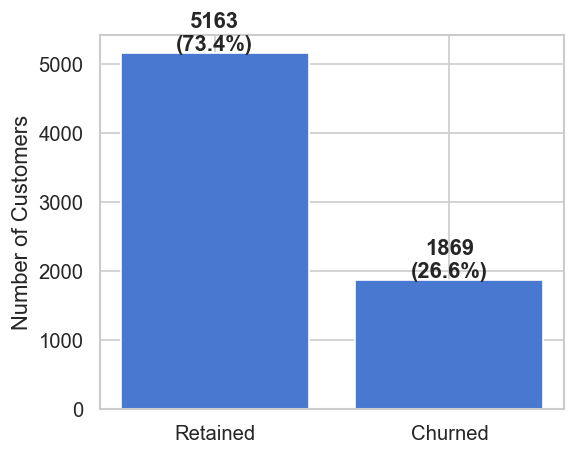

In [28]:
fig, ax = plt.subplots(figsize=(5, 4))
churn_counts = df['Churn'].value_counts()
ax.bar(['Retained', 'Churned'], churn_counts.values)
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 30, f'{v}\n({v/len(df)*100:.1f}%)',ha='center', fontweight='bold')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('plot_01_churn_distribution.png')
plt.show()

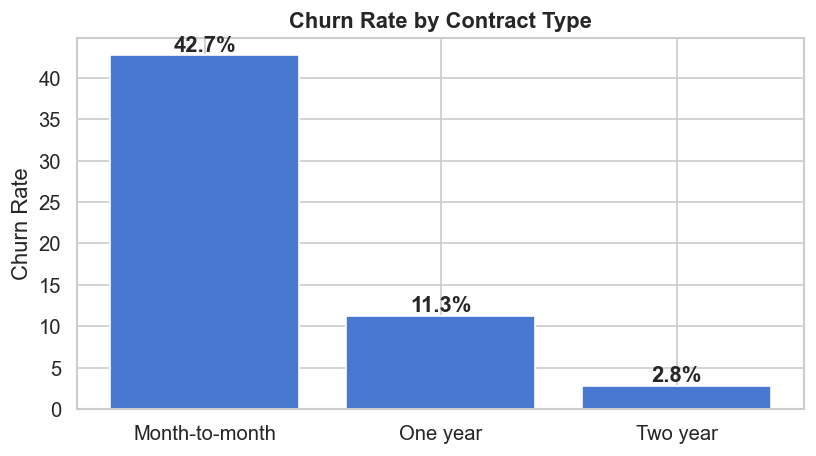

In [30]:
fig, ax = plt.subplots(figsize=(7, 4))
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False) * 100
bars = ax.bar(contract_churn.index, contract_churn.values)
for bar, val in zip(bars, contract_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_title('Churn Rate by Contract Type', fontweight='bold')
ax.set_ylabel('Churn Rate')
plt.tight_layout()
plt.savefig('plot_02_churn_by_contract.png')
plt.show()

In [31]:
for contract, rate in contract_churn.items():
    print(f"{contract}: {rate:.1f}% churn rate")

Month-to-month: 42.7% churn rate
One year: 11.3% churn rate
Two year: 2.8% churn rate


In [32]:
#churn rate by tenure
df['tenure_bucket'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0–12 months', '13–24 months', '25–48 months', '49–72 months'],
    include_lowest=True
)

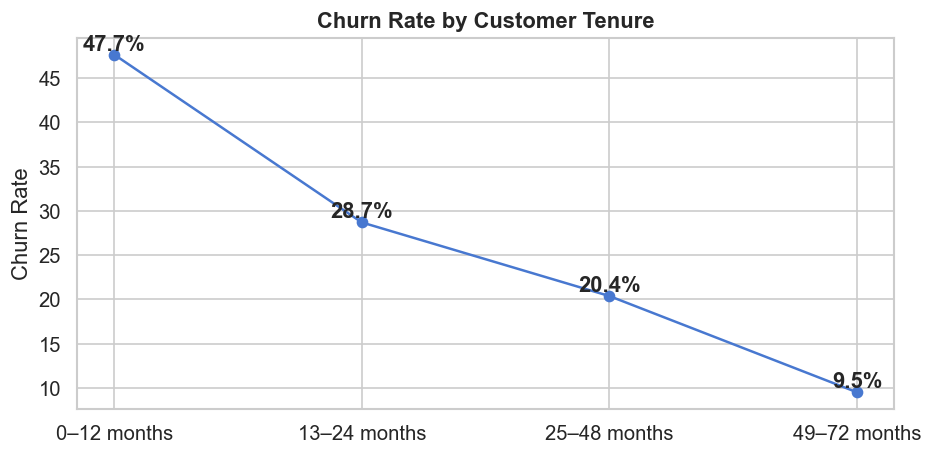

In [36]:
fig, ax = plt.subplots(figsize=(8, 4))
tenure_churn = df.groupby('tenure_bucket', observed=True)['Churn'].mean() * 100
ax.plot(tenure_churn.index, tenure_churn.values,
        marker='o')
for i, val in enumerate(tenure_churn.values):
    ax.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_xticks(range(len(tenure_churn)))
ax.set_xticklabels(tenure_churn.index)
ax.set_title('Churn Rate by Customer Tenure', fontweight='bold')
ax.set_ylabel('Churn Rate')
plt.tight_layout()
plt.savefig('plot_03_churn_by_tenure.png')
plt.show()

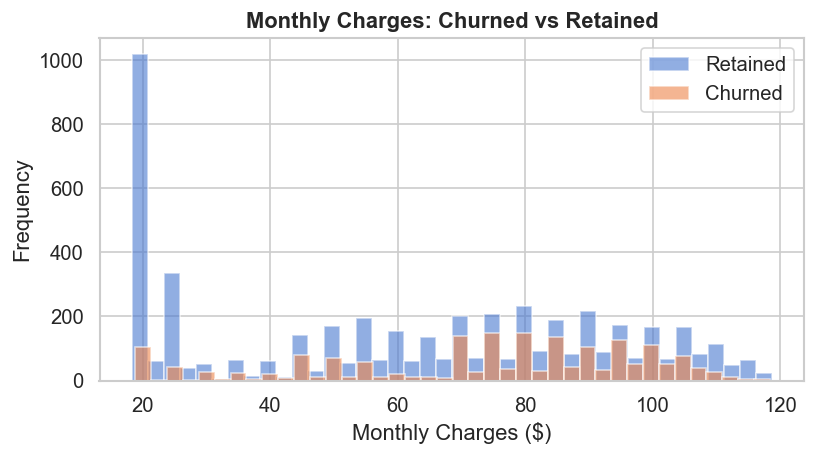

In [37]:
fig, ax = plt.subplots(figsize=(7, 4))
df[df['Churn'] == 0]['MonthlyCharges'].plot(kind='hist', bins=40, alpha=0.6, label='Retained')
df[df['Churn'] == 1]['MonthlyCharges'].plot(kind='hist', bins=40, alpha=0.6, label='Churned')
ax.set_title('Monthly Charges: Churned vs Retained', fontweight='bold')
ax.set_xlabel('Monthly Charges ($)')
ax.legend()
plt.tight_layout()
plt.savefig('plot_04_monthly_charges_distribution.png')
plt.show()

In [38]:
print("Avg monthly charges — Churned: ${:.2f} | Retained: ${:.2f}".format(
    df[df['Churn']==1]['MonthlyCharges'].mean(),
    df[df['Churn']==0]['MonthlyCharges'].mean()
))

Avg monthly charges — Churned: $74.44 | Retained: $61.31


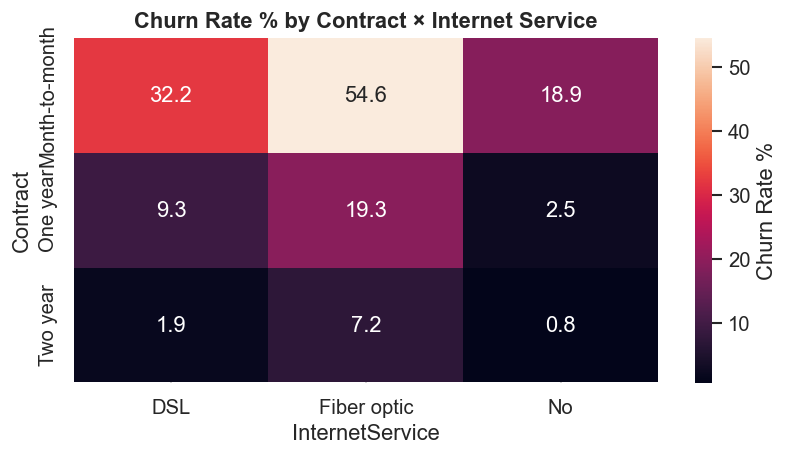

In [39]:
#churn rate by contract x internet service
pivot = df.pivot_table(values='Churn', index='Contract', columns='InternetService', aggfunc='mean') * 100
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cbar_kws={'label': 'Churn Rate %'})
ax.set_title('Churn Rate % by Contract × Internet Service', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_05_churn_heatmap.png')
plt.show()

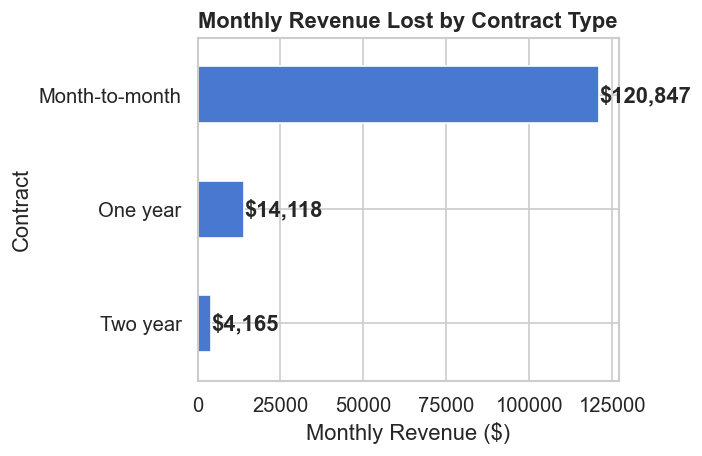

In [40]:
revenue_at_risk = df[df['Churn'] == 1].groupby('Contract')['MonthlyCharges'].sum()
fig, ax = plt.subplots(figsize=(6, 4))
revenue_at_risk.sort_values().plot(kind='barh')
ax.set_title('Monthly Revenue Lost by Contract Type', fontweight='bold')
ax.set_xlabel('Monthly Revenue ($)')
for i, val in enumerate(revenue_at_risk.sort_values().values):
    ax.text(val + 100, i, f'${val:,.0f}', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_06_revenue_at_risk.png')
plt.show()

In [41]:
df_model = df.drop(columns=['tenure_bucket']).copy()

In [42]:
# Separate categorical and numerical columns
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
 
print("Categorical columns to encode:", cat_cols)

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [43]:
# Label encode all categorical columns
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

In [45]:
# Feature matrix and target
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']
print("\Feature matrix shape:", X.shape)
print("Class balance:\n", y.value_counts())

Feature matrix shape: (7032, 19)
Class balance:
 Churn
0    5163
1    1869
Name: count, dtype: int64


In [46]:
 # Scale numerical features
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])
 
# Train / test split — stratified to preserve churn ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")


Train size: 5625 | Test size: 1407


In [48]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10,
                            random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
 
print(classification_report(y_test, rf_preds, target_names=['Retained', 'Churned']))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_proba), 4))

              precision    recall  f1-score   support

    Retained       0.88      0.80      0.84      1033
     Churned       0.56      0.71      0.62       374

    accuracy                           0.77      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.80      0.77      0.78      1407

ROC-AUC: 0.8327


In [49]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # handle imbalance
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]
 
print(classification_report(y_test, xgb_preds, target_names=['Retained', 'Churned']))
print("ROC-AUC:", round(roc_auc_score(y_test, xgb_proba), 4))

              precision    recall  f1-score   support

    Retained       0.89      0.74      0.81      1033
     Churned       0.51      0.75      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.76      1407

ROC-AUC: 0.823


In [50]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_cv_scores = cross_val_score(xgb, X, y, cv=cv, scoring='roc_auc')
print(f"\nXGBoost 5-Fold CV AUC: {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}")


XGBoost 5-Fold CV AUC: 0.8398 ± 0.0043


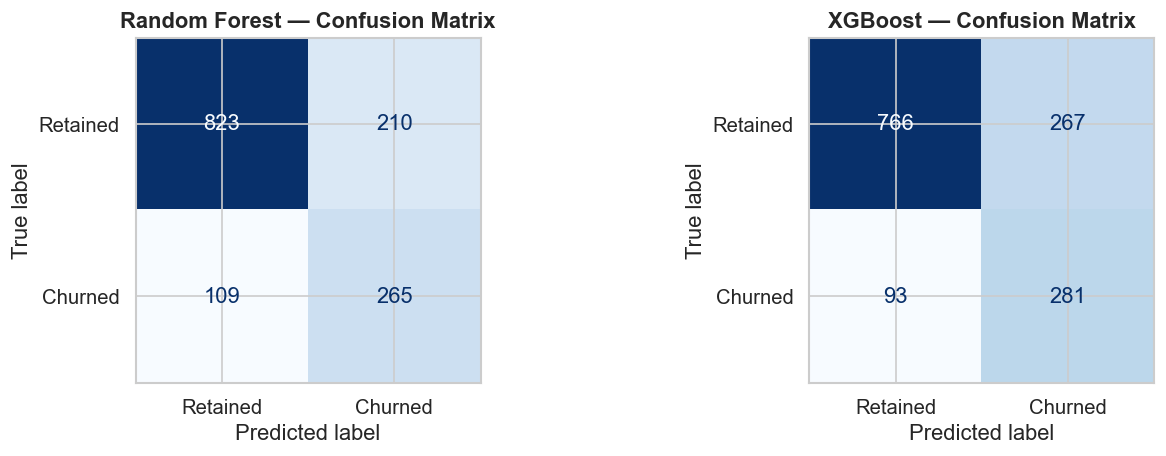

In [54]:
# confusion matrix comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, model, preds, title in zip(
    axes,
    [rf, xgb],
    [rf_preds, xgb_preds],
    ['Random Forest', 'XGBoost']
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title} — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_07_confusion_matrices.png')
plt.show()

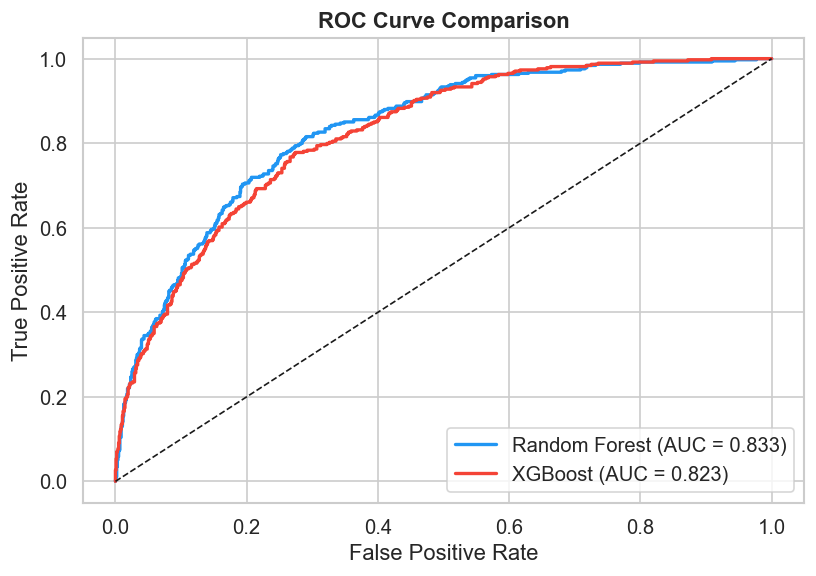

In [55]:
# ROC curve analysis
fig, ax = plt.subplots(figsize=(7, 5))
for proba, label, color in [
    (rf_proba, 'Random Forest', '#2196F3'),
    (xgb_proba, 'XGBoost', '#F44336')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{label} (AUC = {auc:.3f})', color=color, linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_08_roc_curves.png')
plt.show()

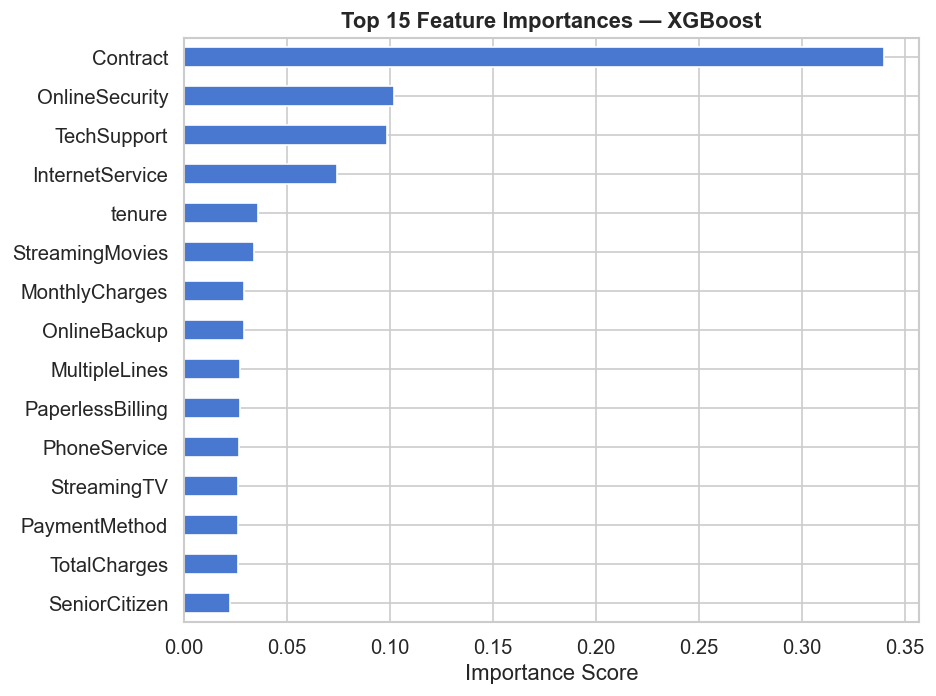

In [56]:
feat_imp = pd.Series(xgb.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True).tail(15)
 
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.plot(kind='barh')
ax.set_title('Top 15 Feature Importances — XGBoost', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot_09_feature_importance.png')
plt.show()

In [57]:
# churn risk scoring
# Assign churn risk scores to ALL customers
df['churn_risk_score'] = xgb.predict_proba(X)[:, 1]
 
# Segment customers by risk tier
df['risk_tier'] = pd.cut(
    df['churn_risk_score'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)
 
risk_summary = df.groupby('risk_tier', observed=True).agg(
    customer_count=('churn_risk_score', 'count'),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    total_monthly_revenue=('MonthlyCharges', 'sum'),
    actual_churn_rate=('Churn', 'mean')
).round(2)

print(risk_summary)
 
# Export risk scores for Power BI dashboard
df[['MonthlyCharges', 'TotalCharges', 'tenure',
    'churn_risk_score', 'risk_tier', 'Churn']].to_csv(
    'customer_risk_scores.csv', index=False
)
print("\nRisk scores exported to customer_risk_scores.csv")

             customer_count  avg_monthly_charges  total_monthly_revenue  \
risk_tier                                                                 
Low Risk               3500                56.38               197318.5   
Medium Risk            1343                69.43                93247.1   
High Risk              2189                75.42               165095.4   

             actual_churn_rate  
risk_tier                       
Low Risk                  0.02  
Medium Risk               0.22  
High Risk                 0.69  

Risk scores exported to customer_risk_scores.csv


In [59]:
total = len(df)
churned = df['Churn'].sum()
churn_rate = churned / total * 100
revenue_at_risk = df[df['Churn'] == 1]['MonthlyCharges'].sum()
high_risk_active = df[(df['risk_tier'] == 'High Risk') & (df['Churn'] == 0)].shape[0]
high_risk_revenue = df[(df['risk_tier'] == 'High Risk') & (df['Churn'] == 0)]['MonthlyCharges'].sum()
top_feature = feat_imp.idxmax()
 
print("\n" + "="*55)
print("       BUSINESS INSIGHT SUMMARY")
print("="*55)
print(f"  Total Customers Analysed : {total:,}")
print(f"  Overall Churn Rate       : {churn_rate:.1f}%")
print(f"  Monthly Revenue Lost     : ${revenue_at_risk:,.2f}")
print(f"  High-Risk Active Customers: {high_risk_active:,}")
print(f"  Revenue at Future Risk   : ${high_risk_revenue:,.2f}")
print(f"  XGBoost Model AUC        : {roc_auc_score(y_test, xgb_proba):.3f}")
print("="*55)
print("\nRECOMMENDATIONS:")
print("  1. Prioritise retention campaigns for Month-to-Month")
print("     contract customers with MonthlyCharges > $60")
print("  2. Offer contract upgrade incentives at tenure month 6–12")
print("     (highest churn window)")
print("  3. Target the", high_risk_active, "high-risk active customers")
print("     before they churn — potential save: ${:,.0f}/month".format(high_risk_revenue))


       BUSINESS INSIGHT SUMMARY
  Total Customers Analysed : 7,032
  Overall Churn Rate       : 26.6%
  Monthly Revenue Lost     : $139,130.85
  High-Risk Active Customers: 687
  Revenue at Future Risk   : $49,737.70
  XGBoost Model AUC        : 0.823

RECOMMENDATIONS:
  1. Prioritise retention campaigns for Month-to-Month
     contract customers with MonthlyCharges > $60
  2. Offer contract upgrade incentives at tenure month 6–12
     (highest churn window)
  3. Target the 687 high-risk active customers
     before they churn — potential save: $49,738/month
